# Descriptive Statistical Analysis

This notebook compares **YOLOv11s** and **Faster R-CNN** using the three matched random seeds.

Because only three paired repetitions are available, the analysis focuses on:

- mean ± standard deviation;
- seed-by-seed paired differences;
- mean and median paired differences;
- paired Cohen's *d* (`d_z`);
- consistency across seeds;
- paired comparison figures;
- automatic academic interpretations.

No ANOVA, t-test, or Wilcoxon significance test is performed.

# Mount Google Drive

In [43]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Imports

In [44]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 300)

print("Imports completed.")


Imports completed.


# Paths

In [45]:
PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks/Dissertation")

# Export produced by Notebook 04: cross dataset generalization
STANDARDISED_RESULTS_PATH = (
    PROJECT_ROOT
    / "Results"
    / "crossdataset_generalization_analysis"
    / "tables"
    / "all_standardised_results.csv"
)

OUTPUT_DIR = (
    PROJECT_ROOT
    / "Results"
    / "descriptive_statistical_analysis"
)

TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"
TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Input file:", STANDARDISED_RESULTS_PATH)
print("Input exists:", STANDARDISED_RESULTS_PATH.exists())
print("Output directory:", OUTPUT_DIR)


Input file: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/crossdataset_generalization_analysis/tables/all_standardised_results.csv
Input exists: True
Output directory: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/descriptive_statistical_analysis


# Load the standardised results

In [46]:
if not STANDARDISED_RESULTS_PATH.exists():
    raise FileNotFoundError(
        "The standardised results file was not found. "
        "Run Notebook 04 first, or update STANDARDISED_RESULTS_PATH."
    )

results_df = pd.read_csv(STANDARDISED_RESULTS_PATH)

print("Rows loaded:", len(results_df))
display(results_df.head())


Rows loaded: 84


,experiment,dataset,source_train_dataset,target_test_dataset,transfer_direction,model,seed,condition,mAP50-95,mAP50,mAP75,Precision,Recall,F1-score,Preprocess_ms_per_image,Inference_ms_per_image,Postprocess_ms_per_image,FPS,source_file
0,in_domain,ACDC,ACDC,ACDC,ACDC in-domain,Faster R-CNN,123,global,0.428254,0.612108,0.455618,NaN,NaN,NaN,NaN,61.770184,NaN,16.189040,faster_rcnn/acdc_in_domain_faster_rcnn_seed123...
1,in_domain,ACDC,ACDC,ACDC,ACDC in-domain,Faster R-CNN,123,fog,0.572156,0.764261,0.621466,NaN,NaN,NaN,NaN,61.786938,NaN,16.184651,faster_rcnn/acdc_in_domain_faster_rcnn_seed123...
2,in_domain,ACDC,ACDC,ACDC,ACDC in-domain,Faster R-CNN,123,rain,0.374499,0.544613,0.388124,NaN,NaN,NaN,NaN,60.997793,NaN,16.394036,faster_rcnn/acdc_in_domain_faster_rcnn_seed123...
3,in_domain,ACDC,ACDC,ACDC,ACDC in-domain,Faster R-CNN,123,snow,0.515350,0.697251,0.567666,NaN,NaN,NaN,NaN,61.904689,NaN,16.153865,faster_rcnn/acdc_in_domain_faster_rcnn_seed123...
4,in_domain,ACDC,ACDC,ACDC,ACDC in-domain,Faster R-CNN,42,global,0.412798,0.596349,0.449924,NaN,NaN,NaN,NaN,62.100221,NaN,16.103002,faster_rcnn/acdc_in_domain_faster_rcnn_seed42/...


# Standardise columns and create scenario labels

In [47]:
numeric_columns = [
    "seed",
    "mAP50-95",
    "mAP50",
    "mAP75",
    "Precision",
    "Recall",
    "F1-score",
    "Preprocess_ms_per_image",
    "Inference_ms_per_image",
    "Postprocess_ms_per_image",
    "FPS",
]

for column in numeric_columns:
    if column in results_df.columns:
        results_df[column] = pd.to_numeric(
            results_df[column],
            errors="coerce",
        )

results_df["condition"] = (
    results_df["condition"]
    .astype(str)
    .str.strip()
    .str.lower()
)

results_df["model"] = (
    results_df["model"]
    .astype(str)
    .str.strip()
)

def build_scenario(row):
    if row["experiment"] == "in_domain":
        return f'{row["dataset"]} in-domain'
    return row["transfer_direction"]

results_df["scenario"] = results_df.apply(build_scenario, axis=1)

display(
    results_df[
        [
            "scenario",
            "experiment",
            "dataset",
            "transfer_direction",
            "model",
            "seed",
            "condition",
        ]
    ]
    .drop_duplicates()
    .sort_values(["scenario", "model", "seed", "condition"])
)


,scenario,experiment,dataset,transfer_direction,model,seed,condition
5,ACDC in-domain,in_domain,ACDC,ACDC in-domain,Faster R-CNN,42,fog
4,ACDC in-domain,in_domain,ACDC,ACDC in-domain,Faster R-CNN,42,global
6,ACDC in-domain,in_domain,ACDC,ACDC in-domain,Faster R-CNN,42,rain
7,ACDC in-domain,in_domain,ACDC,ACDC in-domain,Faster R-CNN,42,snow
1,ACDC in-domain,in_domain,ACDC,ACDC in-domain,Faster R-CNN,123,fog
0,ACDC in-domain,in_domain,ACDC,ACDC in-domain,Faster R-CNN,123,global
2,ACDC in-domain,in_domain,ACDC,ACDC in-domain,Faster R-CNN,123,rain
3,ACDC in-domain,in_domain,ACDC,ACDC in-domain,Faster R-CNN,123,snow
50,ACDC in-domain,in_domain,ACDC,ACDC in-domain,YOLOv11s,42,fog
49,ACDC in-domain,in_domain,ACDC,ACDC in-domain,YOLOv11s,42,global


# Keep global evaluation rows

In [48]:
global_df = results_df[
    results_df["condition"] == "global"
].copy()

print("Global rows:", len(global_df))

coverage_table = (
    global_df
    .groupby(["scenario", "model"], dropna=False)
    .agg(
        rows=("seed", "size"),
        number_of_seeds=("seed", "nunique"),
        seeds=(
            "seed",
            lambda values: ", ".join(
                str(int(value))
                for value in sorted(values.dropna().unique())
            ),
        ),
    )
    .reset_index()
)

display(coverage_table)


Global rows: 24


,scenario,model,rows,number_of_seeds,seeds
0,ACDC in-domain,Faster R-CNN,2,2,"42, 123"
1,ACDC in-domain,YOLOv11s,5,3,"42, 123, 456"
2,ACDC → DAWN,Faster R-CNN,3,3,"42, 123, 456"
3,ACDC → DAWN,YOLOv11s,3,3,"42, 123, 456"
4,DAWN in-domain,Faster R-CNN,3,3,"42, 123, 456"
5,DAWN in-domain,YOLOv11s,2,2,"123, 456"
6,DAWN → ACDC,Faster R-CNN,3,3,"42, 123, 456"
7,DAWN → ACDC,YOLOv11s,3,3,"42, 123, 456"


# Metrics

The main accuracy metric is **mAP50-95**. The other metrics provide supplementary information about detection quality and computational efficiency.


In [49]:
METRICS = [
    "mAP50-95",
    "mAP50",
    "Precision",
    "Recall",
    "F1-score",
    "FPS",
]

available_metrics = [
    metric for metric in METRICS
    if metric in global_df.columns
]

print("Available metrics:", available_metrics)


Available metrics: ['mAP50-95', 'mAP50', 'Precision', 'Recall', 'F1-score', 'FPS']


# Mean ± standard deviation by model and scenario

In [50]:
descriptive_summary = (
    global_df
    .groupby(["scenario", "model"], dropna=False)[available_metrics]
    .agg(["mean", "std", "min", "max"])
    .reset_index()
)

display(descriptive_summary.round(6))


scenario         model  mAP50-95                                \
                                     mean       std       min       max   
0  ACDC in-domain  Faster R-CNN  0.420526  0.010929  0.412798  0.428254   
1  ACDC in-domain      YOLOv11s  0.291909  0.078147  0.206947  0.356363   
2     ACDC → DAWN  Faster R-CNN  0.258917  0.003782  0.254590  0.261593   
3     ACDC → DAWN      YOLOv11s  0.113470  0.016675  0.095681  0.128745   
4  DAWN in-domain  Faster R-CNN  0.449802  0.023990  0.422588  0.467889   
5  DAWN in-domain      YOLOv11s  0.313678  0.054549  0.275106  0.352250   
6     DAWN → ACDC  Faster R-CNN  0.155538  0.005352  0.150596  0.161222   
7     DAWN → ACDC      YOLOv11s  0.082837  0.020554  0.070865  0.106570   

      mAP50                               Precision                      \
       mean       std       min       max      mean       std       min   
0  0.604228  0.011144  0.596349  0.612108       NaN       NaN       NaN   
1  0.469273  0.096579  0.364180  0.548418  0.658345  0.122660  0.524486   
2  0.381259  0.003697  0.377175  0.384376       NaN       NaN       NaN   
3  0.187667  0.019383  0.170482  0.208677  0.422563  0.097696  0.358106   
4  0.697790  0.029478  0.664261  0.719638       NaN       NaN       NaN   
5  0.530220  0.031148  0.508195  0.552245  0.670990  0.051884  0.634303   
6  0.268348  0.009317  0.261861  0.279024       NaN       NaN       NaN   
7  0.150374  0.036976  0.127231  0.193018  0.369606  0.130149  0.279343   

               Recall                                F1-score            \
        max      mean       std       min       max      mean       std   
0       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
1  0.765000  0.421873  0.074939  0.342873  0.491172  0.513839  0.091379   
2       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
3  0.534970  0.165906  0.024679  0.143990  0.192638  0.234520  0.017407   
4       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
5  0.707678  0.430554  0.069869  0.381149  0.479959  0.524079  0.067753   
6       NaN       NaN       NaN       NaN       NaN       NaN       NaN   
7  0.518796  0.165266  0.040237  0.128748  0.208402  0.227884  0.062489   

                              FPS                                       
        min       max        mean         std         min          max  
0       NaN       NaN   16.146021    0.060838   16.103002    16.189040  
1  0.414666  0.590083  928.541682  477.341876   84.532316  1184.467868  
2       NaN       NaN   20.823458    0.514358   20.524758    21.417383  
3  0.222217  0.254437  216.447931   86.883007  127.370364   300.956043  
4       NaN       NaN   20.237553    0.277188   19.998489    20.541394  
5  0.476170  0.571987  599.090713  536.674682  219.604407   978.577020  
6       NaN       NaN    9.761242    6.265521    6.043847    16.995113  
7  0.176259  0.297355  291.857653   14.860641  280.351925   308.635594

# Publication-ready mean ± SD table

In [51]:
def format_mean_std(mean_value, std_value, decimals=4):
    if pd.isna(mean_value):
        return "—"

    if pd.isna(std_value):
        return f"{mean_value:.{decimals}f}"

    return f"{mean_value:.{decimals}f} ± {std_value:.{decimals}f}"


publication_rows = []

for (scenario, model), group in global_df.groupby(
    ["scenario", "model"],
    dropna=False,
):
    row = {
        "scenario": scenario,
        "model": model,
        "number_of_seeds": group["seed"].nunique(),
    }

    for metric in available_metrics:
        decimals = 2 if metric == "FPS" else 4
        row[metric] = format_mean_std(
            group[metric].mean(),
            group[metric].std(ddof=1),
            decimals=decimals,
        )

    publication_rows.append(row)

publication_summary_df = pd.DataFrame(publication_rows)

display(publication_summary_df)


,scenario,model,number_of_seeds,mAP50-95,mAP50,Precision,Recall,F1-score,FPS
0,ACDC in-domain,Faster R-CNN,2,0.4205 ± 0.0109,0.6042 ± 0.0111,—,—,—,16.15 ± 0.06
1,ACDC in-domain,YOLOv11s,3,0.2919 ± 0.0781,0.4693 ± 0.0966,0.6583 ± 0.1227,0.4219 ± 0.0749,0.5138 ± 0.0914,928.54 ± 477.34
2,ACDC → DAWN,Faster R-CNN,3,0.2589 ± 0.0038,0.3813 ± 0.0037,—,—,—,20.82 ± 0.51
3,ACDC → DAWN,YOLOv11s,3,0.1135 ± 0.0167,0.1877 ± 0.0194,0.4226 ± 0.0977,0.1659 ± 0.0247,0.2345 ± 0.0174,216.45 ± 86.88
4,DAWN in-domain,Faster R-CNN,3,0.4498 ± 0.0240,0.6978 ± 0.0295,—,—,—,20.24 ± 0.28
5,DAWN in-domain,YOLOv11s,2,0.3137 ± 0.0545,0.5302 ± 0.0311,0.6710 ± 0.0519,0.4306 ± 0.0699,0.5241 ± 0.0678,599.09 ± 536.67
6,DAWN → ACDC,Faster R-CNN,3,0.1555 ± 0.0054,0.2683 ± 0.0093,—,—,—,9.76 ± 6.27
7,DAWN → ACDC,YOLOv11s,3,0.0828 ± 0.0206,0.1504 ± 0.0370,0.3696 ± 0.1301,0.1653 ± 0.0402,0.2279 ± 0.0625,291.86 ± 14.86


# Paired effect-size helper functions

For each seed:

paired difference = Faster R-CNN − YOLOv11s

Paired Cohen's *d* is calculated as:

d_z = mean of paired differences / standard deviation of paired differences

Interpretation of the absolute value:

- below 0.20: negligible;
- 0.20 to below 0.50: small;
- 0.50 to below 0.80: moderate;
- 0.80 or above: large.

With only three seeds, the magnitude can be unstable. It should be interpreted together with the raw differences and consistency count.


In [52]:
def paired_cohens_dz(differences):
    differences = np.asarray(differences, dtype=float)
    differences = differences[~np.isnan(differences)]

    if len(differences) < 2:
        return np.nan

    difference_std = np.std(differences, ddof=1)

    if np.isclose(difference_std, 0):
        if np.isclose(np.mean(differences), 0):
            return 0.0
        return np.inf * np.sign(np.mean(differences))

    return np.mean(differences) / difference_std


def effect_size_label(effect_size):
    if pd.isna(effect_size):
        return "not available"

    if np.isinf(effect_size):
        return "extremely consistent"

    magnitude = abs(effect_size)

    if magnitude < 0.20:
        return "negligible"
    if magnitude < 0.50:
        return "small"
    if magnitude < 0.80:
        return "moderate"
    return "large"


# Seed-by-seed paired comparison

In [53]:
paired_seed_records = []

for scenario, scenario_df in global_df.groupby("scenario"):
    for metric in available_metrics:
        pivot_df = (
            scenario_df
            .pivot_table(
                index="seed",
                columns="model",
                values=metric,
                aggfunc="mean",
            )
        )

        required_models = {"YOLOv11s", "Faster R-CNN"}

        if not required_models.issubset(pivot_df.columns):
            continue

        paired_df = pivot_df[
            ["YOLOv11s", "Faster R-CNN"]
        ].dropna()

        for seed, row in paired_df.iterrows():
            difference = (
                row["Faster R-CNN"]
                - row["YOLOv11s"]
            )

            if difference > 0:
                winner = "Faster R-CNN"
            elif difference < 0:
                winner = "YOLOv11s"
            else:
                winner = "Tie"

            paired_seed_records.append({
                "scenario": scenario,
                "metric": metric,
                "seed": int(seed),
                "YOLOv11s": row["YOLOv11s"],
                "Faster R-CNN": row["Faster R-CNN"],
                "difference_Faster_minus_YOLO": difference,
                "winner": winner,
            })

paired_seed_df = pd.DataFrame(paired_seed_records)

display(paired_seed_df.round(6))


,scenario,metric,seed,YOLOv11s,Faster R-CNN,difference_Faster_minus_YOLO,winner
0,ACDC in-domain,mAP50-95,42,0.332924,0.412798,0.079874,Faster R-CNN
1,ACDC in-domain,mAP50-95,123,0.356363,0.428254,0.071891,Faster R-CNN
2,ACDC in-domain,mAP50,42,0.521167,0.596349,0.075182,Faster R-CNN
3,ACDC in-domain,mAP50,123,0.548418,0.612108,0.063690,Faster R-CNN
4,ACDC in-domain,FPS,42,84.532316,16.103002,-68.429313,YOLOv11s
5,ACDC in-domain,FPS,123,1097.879235,16.189040,-1081.690194,YOLOv11s
6,ACDC → DAWN,mAP50-95,42,0.115986,0.261593,0.145608,Faster R-CNN
7,ACDC → DAWN,mAP50-95,123,0.128745,0.254590,0.125845,Faster R-CNN
8,ACDC → DAWN,mAP50-95,456,0.095681,0.260568,0.164887,Faster R-CNN
9,ACDC → DAWN,mAP50,42,0.183843,0.382226,0.198383,Faster R-CNN


# Mean difference, effect size, and consistency

In [54]:
comparison_records = []

for (scenario, metric), group in paired_seed_df.groupby(
    ["scenario", "metric"],
    dropna=False,
):
    differences = group[
        "difference_Faster_minus_YOLO"
    ].to_numpy(dtype=float)

    number_of_pairs = len(group)
    faster_wins = int((differences > 0).sum())
    yolo_wins = int((differences < 0).sum())
    ties = int((differences == 0).sum())

    mean_difference = np.mean(differences)
    median_difference = np.median(differences)
    difference_std = (
        np.std(differences, ddof=1)
        if number_of_pairs >= 2
        else np.nan
    )

    effect_size = paired_cohens_dz(differences)

    if mean_difference > 0:
        winner_by_mean = "Faster R-CNN"
    elif mean_difference < 0:
        winner_by_mean = "YOLOv11s"
    else:
        winner_by_mean = "Tie"

    comparison_records.append({
        "scenario": scenario,
        "metric": metric,
        "number_of_paired_seeds": number_of_pairs,
        "paired_seeds": ", ".join(
            str(seed) for seed in sorted(group["seed"].unique())
        ),
        "YOLO_mean": group["YOLOv11s"].mean(),
        "YOLO_std": group["YOLOv11s"].std(ddof=1),
        "Faster_mean": group["Faster R-CNN"].mean(),
        "Faster_std": group["Faster R-CNN"].std(ddof=1),
        "mean_difference_Faster_minus_YOLO": mean_difference,
        "median_difference_Faster_minus_YOLO": median_difference,
        "std_of_paired_differences": difference_std,
        "paired_Cohens_dz": effect_size,
        "effect_size_magnitude": effect_size_label(effect_size),
        "Faster_wins": faster_wins,
        "YOLO_wins": yolo_wins,
        "ties": ties,
        "consistency_Faster": f"{faster_wins}/{number_of_pairs}",
        "consistency_YOLO": f"{yolo_wins}/{number_of_pairs}",
        "winner_by_mean": winner_by_mean,
    })

comparison_summary_df = pd.DataFrame(comparison_records)

display(comparison_summary_df.round(6))


,scenario,metric,number_of_paired_seeds,paired_seeds,YOLO_mean,YOLO_std,Faster_mean,Faster_std,mean_difference_Faster_minus_YOLO,median_difference_Faster_minus_YOLO,std_of_paired_differences,paired_Cohens_dz,effect_size_magnitude,Faster_wins,YOLO_wins,ties,consistency_Faster,consistency_YOLO,winner_by_mean
0,ACDC in-domain,FPS,2,"42, 123",591.205775,716.544478,16.146021,0.060838,-575.059754,-575.059754,716.483640,-0.802614,large,0,2,0,0/2,2/2,YOLOv11s
1,ACDC in-domain,mAP50,2,"42, 123",0.534793,0.019270,0.604228,0.011144,0.069436,0.069436,0.008126,8.545017,large,2,0,0,2/2,0/2,Faster R-CNN
2,ACDC in-domain,mAP50-95,2,"42, 123",0.344643,0.016574,0.420526,0.010929,0.075883,0.075883,0.005645,13.442396,large,2,0,0,2/2,0/2,Faster R-CNN
3,ACDC → DAWN,FPS,3,"42, 123, 456",216.447931,86.883007,20.823458,0.514358,-195.624474,-200.489155,87.340818,-2.239783,large,0,3,0,0/3,3/3,YOLOv11s
4,ACDC → DAWN,mAP50,3,"42, 123, 456",0.187667,0.019383,0.381259,0.003697,0.193591,0.198383,0.023075,8.389727,large,3,0,0,3/3,0/3,Faster R-CNN
5,ACDC → DAWN,mAP50-95,3,"42, 123, 456",0.113470,0.016675,0.258917,0.003782,0.145447,0.145608,0.019521,7.450715,large,3,0,0,3/3,0/3,Faster R-CNN
6,DAWN in-domain,FPS,2,"123, 456",599.090713,536.674682,20.085633,0.123241,-579.005080,-579.005080,536.551441,-1.079123,large,0,2,0,0/2,2/2,YOLOv11s
7,DAWN in-domain,mAP50,2,"123, 456",0.530220,0.031148,0.691950,0.039157,0.161730,0.161730,0.008009,20.193537,large,2,0,0,2/2,0/2,Faster R-CNN
8,DAWN in-domain,mAP50-95,2,"123, 456",0.313678,0.054549,0.440758,0.025697,0.127080,0.127080,0.028852,4.404480,large,2,0,0,2/2,0/2,Faster R-CNN
9,DAWN → ACDC,FPS,3,"42, 123, 456",291.857653,14.860641,9.761242,6.265521,-282.096411,-280.541594,8.869467,-31.805338,large,0,3,0,0/3,3/3,YOLOv11s


# Primary mAP50-95 comparison

In [55]:
primary_map_df = comparison_summary_df[
    comparison_summary_df["metric"] == "mAP50-95"
].copy()

display(
    primary_map_df[
        [
            "scenario",
            "number_of_paired_seeds",
            "paired_seeds",
            "YOLO_mean",
            "YOLO_std",
            "Faster_mean",
            "Faster_std",
            "mean_difference_Faster_minus_YOLO",
            "median_difference_Faster_minus_YOLO",
            "paired_Cohens_dz",
            "effect_size_magnitude",
            "Faster_wins",
            "YOLO_wins",
            "ties",
            "winner_by_mean",
        ]
    ].round(6)
)


,scenario,number_of_paired_seeds,paired_seeds,YOLO_mean,YOLO_std,Faster_mean,Faster_std,mean_difference_Faster_minus_YOLO,median_difference_Faster_minus_YOLO,paired_Cohens_dz,effect_size_magnitude,Faster_wins,YOLO_wins,ties,winner_by_mean
2,ACDC in-domain,2,"42, 123",0.344643,0.016574,0.420526,0.010929,0.075883,0.075883,13.442396,large,2,0,0,Faster R-CNN
5,ACDC → DAWN,3,"42, 123, 456",0.113470,0.016675,0.258917,0.003782,0.145447,0.145608,7.450715,large,3,0,0,Faster R-CNN
8,DAWN in-domain,2,"123, 456",0.313678,0.054549,0.440758,0.025697,0.127080,0.127080,4.404480,large,2,0,0,Faster R-CNN
11,DAWN → ACDC,3,"42, 123, 456",0.082837,0.020554,0.155538,0.005352,0.072702,0.079521,4.605621,large,3,0,0,Faster R-CNN


# Publication-ready comparison table

In [56]:
comparison_publication_rows = []

for _, row in comparison_summary_df.iterrows():
    decimals = 2 if row["metric"] == "FPS" else 4

    effect_value = row["paired_Cohens_dz"]

    if pd.isna(effect_value):
        effect_text = "—"
    elif np.isinf(effect_value):
        sign = "+" if effect_value > 0 else "−"
        effect_text = f"{sign}∞ ({row['effect_size_magnitude']})"
    else:
        effect_text = (
            f"{effect_value:.3f} "
            f"({row['effect_size_magnitude']})"
        )

    comparison_publication_rows.append({
        "scenario": row["scenario"],
        "metric": row["metric"],
        "paired seeds": row["number_of_paired_seeds"],
        "YOLOv11s mean ± SD": format_mean_std(
            row["YOLO_mean"],
            row["YOLO_std"],
            decimals,
        ),
        "Faster R-CNN mean ± SD": format_mean_std(
            row["Faster_mean"],
            row["Faster_std"],
            decimals,
        ),
        "mean difference (Faster − YOLO)": (
            f'{row["mean_difference_Faster_minus_YOLO"]:.{decimals}f}'
        ),
        "paired Cohen's dz": effect_text,
        "Faster wins": (
            f'{row["Faster_wins"]}/'
            f'{row["number_of_paired_seeds"]}'
        ),
        "YOLO wins": (
            f'{row["YOLO_wins"]}/'
            f'{row["number_of_paired_seeds"]}'
        ),
        "winner by mean": row["winner_by_mean"],
    })

comparison_publication_df = pd.DataFrame(
    comparison_publication_rows
)

display(comparison_publication_df)


,scenario,metric,paired seeds,YOLOv11s mean ± SD,Faster R-CNN mean ± SD,mean difference (Faster − YOLO),paired Cohen's dz,Faster wins,YOLO wins,winner by mean
0,ACDC in-domain,FPS,2,591.21 ± 716.54,16.15 ± 0.06,-575.06,-0.803 (large),0/2,2/2,YOLOv11s
1,ACDC in-domain,mAP50,2,0.5348 ± 0.0193,0.6042 ± 0.0111,0.0694,8.545 (large),2/2,0/2,Faster R-CNN
2,ACDC in-domain,mAP50-95,2,0.3446 ± 0.0166,0.4205 ± 0.0109,0.0759,13.442 (large),2/2,0/2,Faster R-CNN
3,ACDC → DAWN,FPS,3,216.45 ± 86.88,20.82 ± 0.51,-195.62,-2.240 (large),0/3,3/3,YOLOv11s
4,ACDC → DAWN,mAP50,3,0.1877 ± 0.0194,0.3813 ± 0.0037,0.1936,8.390 (large),3/3,0/3,Faster R-CNN
5,ACDC → DAWN,mAP50-95,3,0.1135 ± 0.0167,0.2589 ± 0.0038,0.1454,7.451 (large),3/3,0/3,Faster R-CNN
6,DAWN in-domain,FPS,2,599.09 ± 536.67,20.09 ± 0.12,-579.01,-1.079 (large),0/2,2/2,YOLOv11s
7,DAWN in-domain,mAP50,2,0.5302 ± 0.0311,0.6919 ± 0.0392,0.1617,20.194 (large),2/2,0/2,Faster R-CNN
8,DAWN in-domain,mAP50-95,2,0.3137 ± 0.0545,0.4408 ± 0.0257,0.1271,4.404 (large),2/2,0/2,Faster R-CNN
9,DAWN → ACDC,FPS,3,291.86 ± 14.86,9.76 ± 6.27,-282.10,-31.805 (large),0/3,3/3,YOLOv11s


# Consistency table

In [57]:
consistency_df = comparison_summary_df[
    [
        "scenario",
        "metric",
        "number_of_paired_seeds",
        "Faster_wins",
        "YOLO_wins",
        "ties",
        "consistency_Faster",
        "consistency_YOLO",
        "winner_by_mean",
    ]
].copy()

display(consistency_df)


,scenario,metric,number_of_paired_seeds,Faster_wins,YOLO_wins,ties,consistency_Faster,consistency_YOLO,winner_by_mean
0,ACDC in-domain,FPS,2,0,2,0,0/2,2/2,YOLOv11s
1,ACDC in-domain,mAP50,2,2,0,0,2/2,0/2,Faster R-CNN
2,ACDC in-domain,mAP50-95,2,2,0,0,2/2,0/2,Faster R-CNN
3,ACDC → DAWN,FPS,3,0,3,0,0/3,3/3,YOLOv11s
4,ACDC → DAWN,mAP50,3,3,0,0,3/3,0/3,Faster R-CNN
5,ACDC → DAWN,mAP50-95,3,3,0,0,3/3,0/3,Faster R-CNN
6,DAWN in-domain,FPS,2,0,2,0,0/2,2/2,YOLOv11s
7,DAWN in-domain,mAP50,2,2,0,0,2/2,0/2,Faster R-CNN
8,DAWN in-domain,mAP50-95,2,2,0,0,2/2,0/2,Faster R-CNN
9,DAWN → ACDC,FPS,3,0,3,0,0/3,3/3,YOLOv11s


# Paired mAP50-95 figures

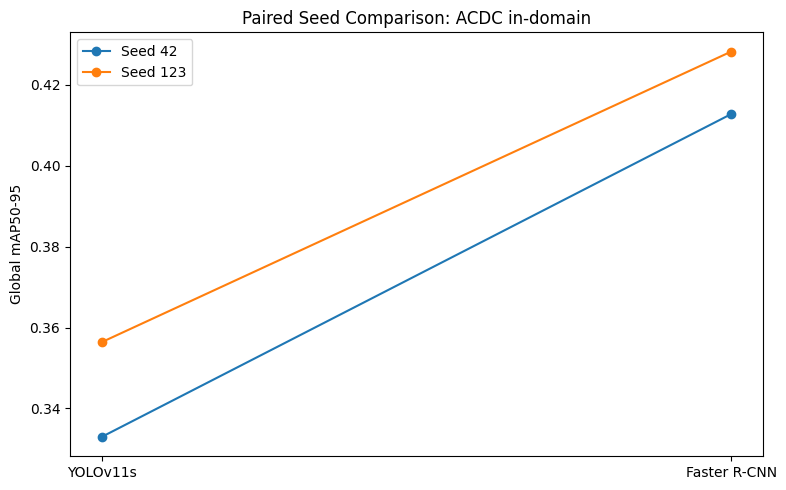

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/descriptive_statistical_analysis/figures/acdc_in_domain_paired_map50_95.png


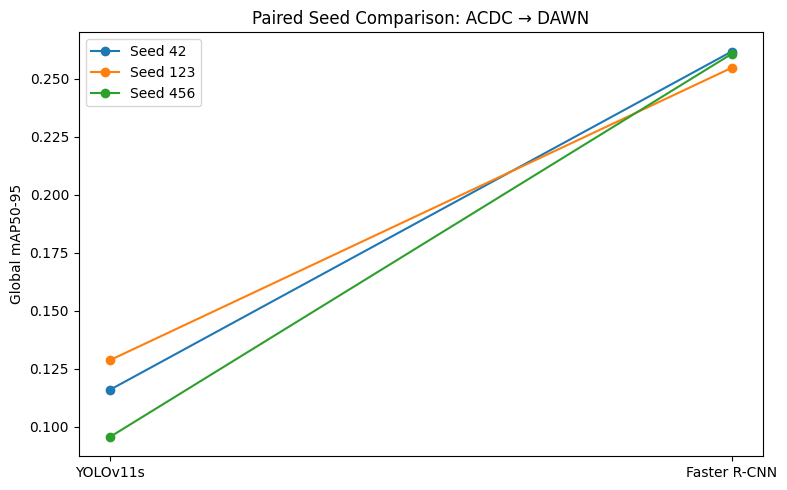

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/descriptive_statistical_analysis/figures/acdc_to_dawn_paired_map50_95.png


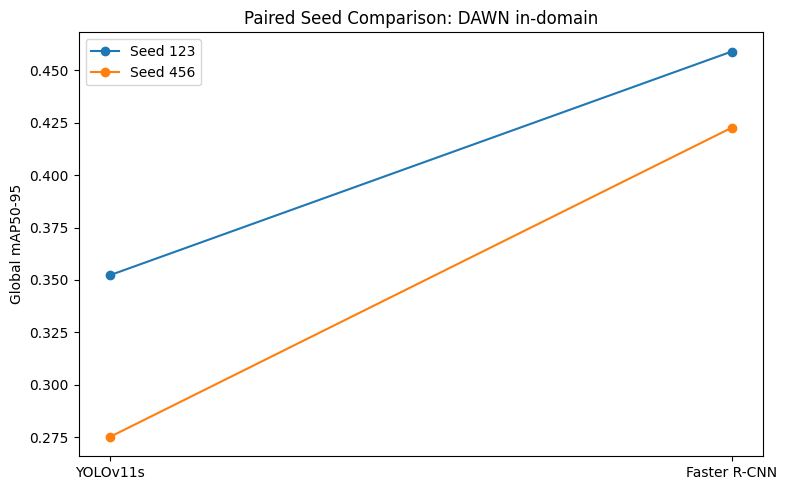

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/descriptive_statistical_analysis/figures/dawn_in_domain_paired_map50_95.png


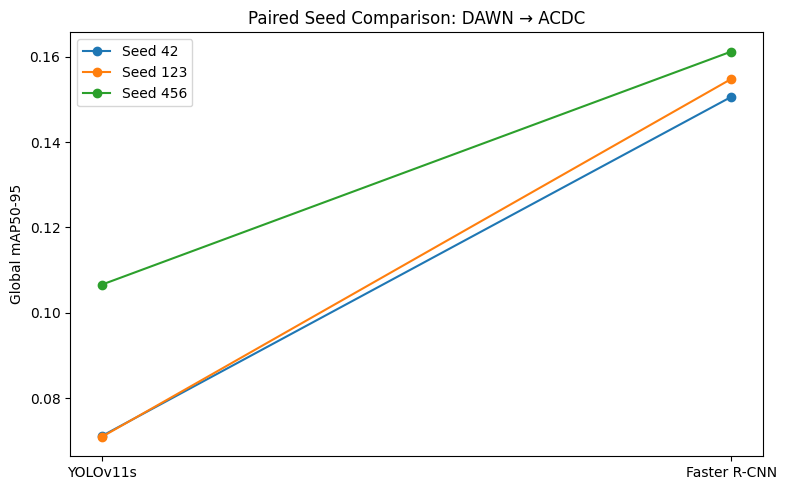

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/descriptive_statistical_analysis/figures/dawn_to_acdc_paired_map50_95.png


In [58]:
map_seed_df = paired_seed_df[
    paired_seed_df["metric"] == "mAP50-95"
].copy()

if map_seed_df.empty:
    print("No paired mAP50-95 values were available.")

else:
    for scenario in map_seed_df["scenario"].unique():
        scenario_df = map_seed_df[
            map_seed_df["scenario"] == scenario
        ].copy()

        plt.figure(figsize=(8, 5))

        for _, row in scenario_df.iterrows():
            plt.plot(
                ["YOLOv11s", "Faster R-CNN"],
                [row["YOLOv11s"], row["Faster R-CNN"]],
                marker="o",
                label=f'Seed {int(row["seed"])}',
            )

        plt.ylabel("Global mAP50-95")
        plt.title(f"Paired Seed Comparison: {scenario}")
        plt.legend()
        plt.tight_layout()

        safe_name = (
            scenario.lower()
            .replace(" → ", "_to_")
            .replace(" ", "_")
            .replace("-", "_")
        )

        figure_path = (
            FIGURES_DIR
            / f"{safe_name}_paired_map50_95.png"
        )

        plt.savefig(
            figure_path,
            dpi=300,
            bbox_inches="tight",
        )
        plt.show()

        print("Saved:", figure_path)


# Mean mAP50-95 comparison figure

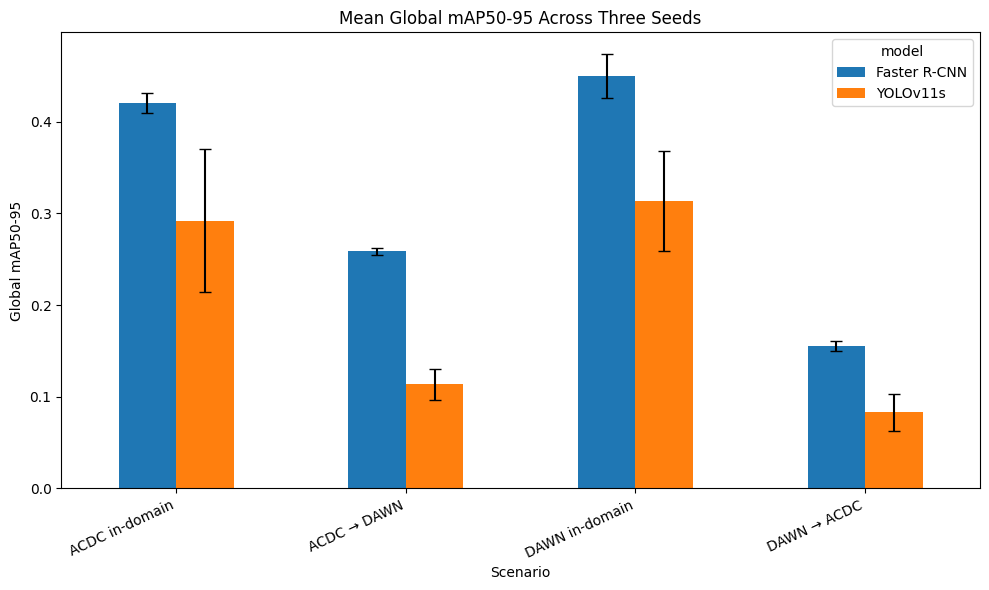

Saved: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/descriptive_statistical_analysis/figures/mean_map50_95_with_standard_deviation.png


In [59]:
map_means_df = (
    global_df
    .groupby(["scenario", "model"])["mAP50-95"]
    .agg(["mean", "std"])
    .reset_index()
)

if map_means_df.empty:
    print("No mAP50-95 values were available.")

else:
    pivot_mean = map_means_df.pivot(
        index="scenario",
        columns="model",
        values="mean",
    )

    pivot_std = map_means_df.pivot(
        index="scenario",
        columns="model",
        values="std",
    )

    ax = pivot_mean.plot(
        kind="bar",
        yerr=pivot_std,
        capsize=4,
        figsize=(10, 6),
    )

    ax.set_ylabel("Global mAP50-95")
    ax.set_xlabel("Scenario")
    ax.set_title("Mean Global mAP50-95 Across Three Seeds")
    plt.xticks(rotation=25, ha="right")
    plt.tight_layout()

    figure_path = (
        FIGURES_DIR
        / "mean_map50_95_with_standard_deviation.png"
    )

    plt.savefig(
        figure_path,
        dpi=300,
        bbox_inches="tight",
    )
    plt.show()

    print("Saved:", figure_path)


# Automatic academic interpretation

In [61]:
interpretation_paragraphs = []

for _, row in primary_map_df.iterrows():
    scenario = row["scenario"]
    number_of_pairs = int(row["number_of_paired_seeds"])

    yolo_text = format_mean_std(
        row["YOLO_mean"],
        row["YOLO_std"],
        decimals=4,
    )

    faster_text = format_mean_std(
        row["Faster_mean"],
        row["Faster_std"],
        decimals=4,
    )

    mean_difference = row[
        "mean_difference_Faster_minus_YOLO"
    ]

    effect_size = row["paired_Cohens_dz"]

    if pd.isna(effect_size):
        effect_text = "could not be calculated"
    elif np.isinf(effect_size):
        effect_text = (
            "was infinite because the paired differences were "
            "identical across seeds"
        )
    else:
        effect_text = (
            f"was {effect_size:.3f}, representing a "
            f"{row['effect_size_magnitude']} effect"
        )

    if row["Faster_wins"] == number_of_pairs:
        consistency_sentence = (
            f"Faster R-CNN outperformed YOLOv11s for all "
            f"{number_of_pairs} paired seeds."
        )
    elif row["YOLO_wins"] == number_of_pairs:
        consistency_sentence = (
            f"YOLOv11s outperformed Faster R-CNN for all "
            f"{number_of_pairs} paired seeds."
        )
    else:
        consistency_sentence = (
            f"Faster R-CNN achieved the higher value for "
            f"{int(row['Faster_wins'])} of {number_of_pairs} seeds, "
            f"while YOLOv11s achieved the higher value for "
            f"{int(row['YOLO_wins'])} seeds."
        )

    interpretation_paragraphs.append(
        f"For {scenario}, YOLOv11s obtained a mean global mAP50-95 "
        f"of {yolo_text}, while Faster R-CNN obtained {faster_text}. "
        f"The mean paired difference, calculated as Faster R-CNN "
        f"minus YOLOv11s, was {mean_difference:.4f}. "
        f"The paired Cohen's d_z effect size {effect_text}. "
        f"{consistency_sentence} Because only three paired seeds were "
        "available, these values are interpreted descriptively and no "
        "claim of statistical significance is made."
    )

interpretation_text = "\n\n".join(
    interpretation_paragraphs
)

print(interpretation_text)


For ACDC in-domain, YOLOv11s obtained a mean global mAP50-95 of 0.3446 ± 0.0166, while Faster R-CNN obtained 0.4205 ± 0.0109. The mean paired difference, calculated as Faster R-CNN minus YOLOv11s, was 0.0759. The paired Cohen's d_z effect size was 13.442, representing a large effect. Faster R-CNN outperformed YOLOv11s for all 2 paired seeds. Because only three paired seeds were available, these values are interpreted descriptively and no claim of statistical significance is made.

For ACDC → DAWN, YOLOv11s obtained a mean global mAP50-95 of 0.1135 ± 0.0167, while Faster R-CNN obtained 0.2589 ± 0.0038. The mean paired difference, calculated as Faster R-CNN minus YOLOv11s, was 0.1454. The paired Cohen's d_z effect size was 7.451, representing a large effect. Faster R-CNN outperformed YOLOv11s for all 3 paired seeds. Because only three paired seeds were available, these values are interpreted descriptively and no claim of statistical significance is made.

For DAWN in-domain, YOLOv11s obt

# Export OUtput

In [63]:
coverage_table.to_csv(
    TABLES_DIR / "seed_coverage.csv",
    index=False,
)

descriptive_summary.to_csv(
    TABLES_DIR / "descriptive_statistics_full.csv",
    index=False,
)

publication_summary_df.to_csv(
    TABLES_DIR / "mean_standard_deviation_table.csv",
    index=False,
)

paired_seed_df.to_csv(
    TABLES_DIR / "seed_by_seed_comparisons.csv",
    index=False,
)

comparison_summary_df.to_csv(
    TABLES_DIR / "paired_effect_size_and_consistency.csv",
    index=False,
)

comparison_publication_df.to_csv(
    TABLES_DIR / "publication_ready_comparison_table.csv",
    index=False,
)

primary_map_df.to_csv(
    TABLES_DIR / "primary_map50_95_analysis.csv",
    index=False,
)

consistency_df.to_csv(
    TABLES_DIR / "consistency_table.csv",
    index=False,
)

with open(
    OUTPUT_DIR / "automatic_academic_interpretation.txt",
    "w",
    encoding="utf-8",
) as file:
    file.write(interpretation_text)
print("Exports completed.")
print("Tables:", TABLES_DIR)
print("Figures:", FIGURES_DIR)
print("Output directory:", OUTPUT_DIR)


Exports completed.
Tables: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/descriptive_statistical_analysis/tables
Figures: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/descriptive_statistical_analysis/figures
Output directory: /content/drive/MyDrive/Colab Notebooks/Dissertation/Results/descriptive_statistical_analysis
